# MetaCerberus Rhizobium FOAM Output to pyGAGE + Pathview Plus

Dr. White confirmed that the relevant starting point is the rhizobium FOAM output from the MetaCerberus repository.

My goal is to test whether existing MetaCerberus functional output can be connected to the newer Python pyGAGE and Pathview Plus workflow.

The first step is to inspect the FOAM output table so I understand what the rows and columns represent before running enrichment or visualization.

In [1]:
!git clone https://github.com/raw-lab/MetaCerberus.git
%cd MetaCerberus

Cloning into 'MetaCerberus'...
remote: Enumerating objects: 30299, done.
remote: Counting objects: 100% (202/202), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 30299 (delta 136), reused 114 (delta 85), pack-reused 30097 (from 3)
Receiving objects: 100% (30299/30299), 543.16 MiB | 16.80 MiB/s, done.
Resolving deltas: 100% (10794/10794), done.
Updating files: 100% (17986/17986), done.
/content/MetaCerberus


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import polars as pl

In [3]:
foam_path = Path("results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/FOAM_Loading_Matrix.tsv")

print("Exists:", foam_path.exists())
print("Path:", foam_path)

Exists: True
Path: results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/FOAM_Loading_Matrix.tsv


In [4]:
!head -n 10 results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/FOAM_Loading_Matrix.tsv

ID	PC1	PC2	PC3	PC4	PC5	PC6	PC7	PC8	PC9	PC10
K00001	-1.0534821500848774	-0.03264380845011642	-0.0035755501030547043	-0.0038976859131693424	-0.012585790119650891	0.0021470717428785837	-7.363749333183233e-05	-0.003007833289990717	-0.0045619410251867085	1.4748875507802754e-15
K00003	-1.0534821500848783	-0.03264380845011664	-0.0035755501030603704	-0.0038976859131703004	-0.012585790119654564	0.00214707174287758	-7.363749333273928e-05	-0.003007833289989974	-0.004561941025186169	-2.1146070532037617e-15
K00004	-0.4325823985693577	-0.2003808796260604	0.4669112669610754	-0.06516457575307807	0.6350508031578735	0.003823764219992661	0.48071723665199456	-0.01169730590633042	-0.16446427316304746	6.368251487765999e-15
K00012	1.4197079668095802e-15	-9.066126310027342e-17	9.566371682358322e-15	4.091791943293745e-15	-3.026026132348632e-15	-1.4127090303981107e-15	8.370567806079817e-16	-6.596863270209055e-15	5.751089519572447e-15	5.453114909629766e-17
K00013	1.5538589101880573e-15	-1.0004231558736763e-16	-3

In [5]:
foam_df = pd.read_csv(foam_path, sep="\t")

print("Shape:", foam_df.shape)
print("Columns:")
print(foam_df.columns.tolist())

display(foam_df.head(10))

Shape: (1112, 11)
Columns:
['ID', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']


,ID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,K00001,-1.053482e+00,-3.264381e-02,-3.575550e-03,-3.897686e-03,-1.258579e-02,2.147072e-03,-7.363749e-05,-3.007833e-03,-4.561941e-03,1.474888e-15
1,K00003,-1.053482e+00,-3.264381e-02,-3.575550e-03,-3.897686e-03,-1.258579e-02,2.147072e-03,-7.363749e-05,-3.007833e-03,-4.561941e-03,-2.114607e-15
2,K00004,-4.325824e-01,-2.003809e-01,4.669113e-01,-6.516458e-02,6.350508e-01,3.823764e-03,4.807172e-01,-1.169731e-02,-1.644643e-01,6.368251e-15
3,K00012,1.419708e-15,-9.066126e-17,9.566372e-15,4.091792e-15,-3.026026e-15,-1.412709e-15,8.370568e-16,-6.596863e-15,5.751090e-15,5.453115e-17
4,K00013,1.553859e-15,-1.000423e-16,-3.443157e-15,-1.845872e-15,-1.118393e-17,3.600418e-16,2.150745e-16,9.150564e-16,-9.146186e-16,-1.529157e-15
5,K00014,-1.092432e-17,-5.998440e-19,1.997915e-16,1.013562e-16,2.918530e-16,1.593568e-16,-3.615965e-17,-1.542037e-16,1.286398e-16,6.609785e-18
6,K00016,1.053482e+00,3.264381e-02,3.575550e-03,3.897686e-03,1.258579e-02,-2.147072e-03,7.363749e-05,3.007833e-03,4.561941e-03,-1.981193e-15
7,K00020,-1.080571e-16,2.842860e-16,5.069194e-15,2.734218e-15,-2.062364e-15,-6.643876e-16,-4.951772e-16,-3.503705e-15,3.357103e-15,9.065985e-17
8,K00023,-1.053482e+00,-3.264381e-02,-3.575550e-03,-3.897686e-03,-1.258579e-02,2.147072e-03,-7.363749e-05,-3.007833e-03,-4.561941e-03,-1.124965e-14
9,K00024,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00


In [6]:
first_col = foam_df.columns[0]

numeric_cols = foam_df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [col for col in foam_df.columns if col not in numeric_cols]

print("First column:", first_col)
print("Numeric columns:", numeric_cols)
print("Non-numeric columns:", non_numeric_cols)

display(foam_df[first_col].head(20))

First column: ID
Numeric columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']
Non-numeric columns: ['ID']


,ID
0,K00001
1,K00003
2,K00004
3,K00012
4,K00013
5,K00014
6,K00016
7,K00020
8,K00023
9,K00024


In [7]:
combined_dir = foam_path.parent

print("Files in combined output folder:")
for file in sorted(combined_dir.iterdir()):
    print(file.name)

Files in combined output folder:
FOAM_Loading_Matrix.tsv
FOAM_Loadings.tsv
FOAM_PCA.htm
KEGG_Loading_Matrix.tsv
KEGG_Loadings.tsv
KEGG_PCA.htm
counts_FOAM.tsv
counts_KEGG.tsv
img
pathview
stats.html
stats.tsv


In [8]:
!find results/rhizobium/23-06-01_rhizobium -type f | grep -Ei "foam|ko|kegg|gage|pathview|class|sample|metadata|matrix|tsv|csv|xlsx"

results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_GIC31_complete/filtered.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_GIC31_complete/FragGeneScan_GIC31_complete.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_gsB_3841/filtered.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_gsB_3841/FragGeneScan_gsB_3841.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_gsA_SM152B/filtered.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_gsA_SM152B/FragGeneScan_gsA_SM152B.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_RW2_complete/filtered.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_RW2_complete/FragGeneScan_RW2_complete.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_gsD_SM51/filtered.tsv
results/rhizobium/23-06-01_rhizobium/step_08-hmmer/FragGeneScan_gsD_SM51/FragGeneScan_gsD_SM51.tsv
results/rhizobium/23-06-01_rhizobium/st

## Goal

The goal of this notebook is to test the handoff between MetaCerberus output and the pyGAGE/Pathview Plus workflow.

MetaCerberus already produces functional annotation outputs. pyGAGE and Pathview Plus provide a Python-native way to move from functional signal to pathway-level interpretation and visualization.

For this first pass, I am using the rhizobium FOAM output because Rhizobium is biologically connected to nitrogen fixation, and Dr. White confirmed this was the correct output to start from.

The main goal is not just to run a function. The goal is to understand the data structure, identify what the rows and columns represent, and figure out which parts of the MetaCerberus output are best suited for pyGAGE and which parts are best suited for Pathview Plus.

## Why I am inspecting before analysis

This step matters because MetaCerberus output is different from the RNA-seq expression matrix I used in the GSE50760 walkthrough.

In the GSE50760 workflow, rows were genes and columns were biological samples. Here, the FOAM output may represent functional annotations, pathway-related features, or already processed loading values.

Before running pyGAGE, I need to understand:

1. what each row represents,
2. what each column represents,
3. whether the values are counts, loadings, normalized values, or summaries,
4. whether there is a sample or class file that defines comparisons,
5. whether the table is already transformed for visualization.

This is important because the analysis should follow the structure of the data instead of forcing the data into the wrong format.

## FOAM versus KEGG/KO handoff

One important thing I am checking is whether the FOAM loading matrix is the right table for both pyGAGE and Pathview Plus, or whether the workflow needs two related inputs.

The FOAM table may be useful for functional level analysis, especially because it captures functional annotation output from MetaCerberus. However, Pathview Plus pathway visualization may require KEGG compatible identifiers such as KO IDs or Entrez style identifiers, depending on the pathway being drawn.

If the FOAM table does not map directly into Pathview Plus, that does not mean the workflow failed. It means the MetaCerberus to pyGAGE handoff and the MetaCerberus to Pathview handoff may need to use different output tables.

## Moving from loading matrices to count tables

The first FOAM file I inspected was `FOAM_Loading_Matrix.tsv`, but that table has principal component columns like `PC1`, `PC2`, and so on. That makes it look more like a loading or visualization summary table instead of the main matrix I would want to use for pyGAGE.

So instead of forcing that table into the workflow, I am moving one layer closer to the count data and inspecting the count tables in the same MetaCerberus output folder.

The files I want to look at next are:

`counts_FOAM.tsv`  
`counts_KEGG.tsv`

My current thinking is that the FOAM count table may be useful for functional-level analysis, while the KEGG count table may be better for the Pathview Plus side because KEGG identifiers should connect more naturally to pathway maps.

The main goal here is to figure out which MetaCerberus output belongs to which part of the workflow, instead of assuming one table should work for everything.

In [9]:
#check if they exist
counts_foam_path = combined_dir / "counts_FOAM.tsv"
counts_kegg_path = combined_dir / "counts_KEGG.tsv"
stats_path = combined_dir / "stats.tsv"
pathview_output_dir = combined_dir / "pathview"

print("counts_FOAM exists:", counts_foam_path.exists())
print("counts_KEGG exists:", counts_kegg_path.exists())
print("stats exists:", stats_path.exists())
print("pathview folder exists:", pathview_output_dir.exists())

counts_FOAM exists: True
counts_KEGG exists: True
stats exists: True
pathview folder exists: True


In [10]:
counts_foam = pd.read_csv(counts_foam_path, sep="\t")
counts_kegg = pd.read_csv(counts_kegg_path, sep="\t")

print("FOAM counts shape:", counts_foam.shape)
print("FOAM columns:")
print(counts_foam.columns.tolist())
display(counts_foam.head(10))

print("\nKEGG counts shape:", counts_kegg.shape)
print("KEGG columns:")
print(counts_kegg.columns.tolist())
display(counts_kegg.head(10))

FOAM counts shape: (1112, 11)
FOAM columns:
['ID', 'GIC31_complete', 'JQGI01_HUD', 'RW2_complete', 'S17', 'SH31', 'gsA_SM152B', 'gsB_3841', 'gsC_SM41', 'gsD_SM51', 'gsE_BIHB1217']


,ID,GIC31_complete,JQGI01_HUD,RW2_complete,S17,SH31,gsA_SM152B,gsB_3841,gsC_SM41,gsD_SM51,gsE_BIHB1217
0,K00001,0,0,0,0,0,1,1,1,1,1
1,K00003,0,0,0,0,0,1,1,1,1,1
2,K00004,0,0,0,0,1,0,0,1,1,1
3,K00012,1,1,1,1,1,1,1,1,1,1
4,K00013,1,1,1,1,1,1,1,1,1,1
5,K00014,1,1,1,1,1,1,1,1,1,1
6,K00016,1,1,1,1,1,0,0,0,0,0
7,K00020,1,1,1,1,1,1,1,1,1,1
8,K00023,0,0,0,0,0,1,1,1,1,1
9,K00024,1,1,1,1,1,1,1,1,1,1



KEGG counts shape: (4340, 11)
KEGG columns:
['ID', 'GIC31_complete', 'JQGI01_HUD', 'RW2_complete', 'S17', 'SH31', 'gsA_SM152B', 'gsB_3841', 'gsC_SM41', 'gsD_SM51', 'gsE_BIHB1217']


,ID,GIC31_complete,JQGI01_HUD,RW2_complete,S17,SH31,gsA_SM152B,gsB_3841,gsC_SM41,gsD_SM51,gsE_BIHB1217
0,K00001,0,0,0,0,0,1,1,1,1,1
1,K00002,0,0,0,0,0,1,0,0,0,0
2,K00003,0,0,0,0,0,1,1,1,1,1
3,K00004,0,0,0,0,1,0,0,1,1,1
4,K00005,1,1,1,1,1,0,0,0,0,0
5,K00008,0,0,1,0,0,1,1,1,1,1
6,K00009,1,1,1,0,1,0,0,0,0,0
7,K00010,0,1,0,0,0,1,1,1,1,1
8,K00012,1,1,1,1,1,1,1,1,1,1
9,K00013,1,1,1,1,1,1,1,1,1,1


## Why the count table is mostly 0 and 10 (why is it different than the GEO dataset)

The KEGG and FOAM count tables appear to contain mostly binary values.

In this context, the values likely represent functional presence or absence across genomes/samples rather than RNA-seq expression levels. A value of `1` means the KEGG or FOAM function was detected in that sample, while a value of `0` means it was not detected.

This changes the biological interpretation. In the GSE50760 RNA-seq workflow, pyGAGE was testing expression shifts between tissue groups. Here, the MetaCerberus output is closer to a functional potential matrix, where the question is whether certain functional pathways are more represented across one set of genomes than another.

Because of that, I should avoid language like “upregulated” unless I am using expression data. For this table, better language would be “more present,” “more represented,” or “more enriched in functional potential.” (Noting this for the readme.md)

In [11]:
sample_cols = [col for col in counts_kegg.columns if col != "ID"]

sample_metadata = pd.DataFrame({
    "sample": sample_cols
})

sample_metadata["prefix"] = sample_metadata["sample"].str.extract(r"^([^_]+)")
sample_metadata["suffix"] = sample_metadata["sample"].str.extract(r"_([^_]+)$")

display(sample_metadata)

,sample,prefix,suffix
0,GIC31_complete,GIC31,complete
1,JQGI01_HUD,JQGI01,HUD
2,RW2_complete,RW2,complete
3,S17,S17,NaN
4,SH31,SH31,NaN
5,gsA_SM152B,gsA,SM152B
6,gsB_3841,gsB,3841
7,gsC_SM41,gsC,SM41
8,gsD_SM51,gsD,SM51
9,gsE_BIHB1217,gsE,BIHB1217


## Sample column checkpoint

The KEGG and FOAM count tables have 10 sample columns.

The sample names appear to split into two rough naming patterns: named/complete samples such as `GIC31_complete`, `JQGI01_HUD`, `RW2_complete`, `S17`, and `SH31`, and `gs` samples such as `gsA_SM152B`, `gsB_3841`, `gsC_SM41`, `gsD_SM51`, and `gsE_BIHB1217`.

I do not want to assume the biological comparison yet, so my next step is to inspect the existing stats table and search for class/sample metadata. If the repository already defines the comparison, I should use that instead of inventing one from the column names.

## Defining the comparison from the repo

The MetaCerberus rhizobium test README defines two groups: Rhizobium and Non-Rhizobium.

The count table contains five Rhizobium columns and five Non-Rhizobium columns, so I can use this as the comparison structure for pyGAGE.

Because the values are mostly 0 and 1, this should be interpreted as functional presence/absence across genomes, not RNA-seq expression.

## Defining groups from the MetaCerberus test data

The MetaCerberus rhizobium test README defines the sample groups as Rhizobium and Non-Rhizobium.

The KEGG count table contains five Rhizobium samples and five Non-Rhizobium samples from that test set. I am using those repo-defined groups to set up the comparison instead of guessing from the sample names.

One Rhizobium sample listed in the README, `gsF_Vaf-108`, is not present in this specific `counts_KEGG.tsv` output, so I am only using the samples that are actually present in the count matrix.

In [12]:
rhizobium_cols = ["gsA_SM152B", "gsB_3841", "gsC_SM41", "gsD_SM51", "gsE_BIHB1217"]

non_rhizobium_cols = ["JQGI01_HUD", "RW2_complete", "SH31", "GIC31_complete", "S17"]

print("Rhizobium columns:", rhizobium_cols)
print("Non-Rhizobium columns:", non_rhizobium_cols)

print("All Rhizobium columns present:", all(col in counts_kegg.columns for col in rhizobium_cols))
print("All Non-Rhizobium columns present:", all(col in counts_kegg.columns for col in non_rhizobium_cols))

Rhizobium columns: ['gsA_SM152B', 'gsB_3841', 'gsC_SM41', 'gsD_SM51', 'gsE_BIHB1217']
Non-Rhizobium columns: ['JQGI01_HUD', 'RW2_complete', 'SH31', 'GIC31_complete', 'S17']
All Rhizobium columns present: True
All Non-Rhizobium columns present: True


## Comparison setup

The repo-defined groups match the columns in the KEGG count table.

For this first test, I am comparing:

`Non-Rhizobium` versus `Rhizobium`

Because the count table values are mostly binary, I am treating this as a functional presence/absence comparison rather than an expression comparison.

In other words, the question is not “which genes are upregulated?” The question is closer to:

Which KEGG functions are more represented in the Rhizobium genomes compared with the Non-Rhizobium genomes?

For pyGAGE, I will use the Non-Rhizobium samples as the reference group and the Rhizobium samples as the comparison group.

In [13]:
# Reorder the KEGG count table for pyGAGE
# ID column first, then reference group, then comparison group

kegg_pygage_input = counts_kegg[["ID"] + non_rhizobium_cols + rhizobium_cols].copy()

print("pyGAGE input shape:", kegg_pygage_input.shape)
print("Columns:")
print(kegg_pygage_input.columns.tolist())

display(kegg_pygage_input.head(10))

pyGAGE input shape: (4340, 11)
Columns:
['ID', 'JQGI01_HUD', 'RW2_complete', 'SH31', 'GIC31_complete', 'S17', 'gsA_SM152B', 'gsB_3841', 'gsC_SM41', 'gsD_SM51', 'gsE_BIHB1217']


,ID,JQGI01_HUD,RW2_complete,SH31,GIC31_complete,S17,gsA_SM152B,gsB_3841,gsC_SM41,gsD_SM51,gsE_BIHB1217
0,K00001,0,0,0,0,0,1,1,1,1,1
1,K00002,0,0,0,0,0,1,0,0,0,0
2,K00003,0,0,0,0,0,1,1,1,1,1
3,K00004,0,0,1,0,0,0,0,1,1,1
4,K00005,1,1,1,1,1,0,0,0,0,0
5,K00008,0,1,0,0,0,1,1,1,1,1
6,K00009,1,1,1,1,0,0,0,0,0,0
7,K00010,1,0,0,0,0,1,1,1,1,1
8,K00012,1,1,1,1,1,1,1,1,1,1
9,K00013,1,1,1,1,1,1,1,1,1,1


## Preparing the Rhizobium vs Non-Rhizobium comparison for pyGAGE

The KEGG count table is now organized with the `ID` column first, followed by the Non-Rhizobium reference samples and then the Rhizobium comparison samples.

This is the first pyGAGE-ready matrix for this notebook.

Because the values are binary presence/absence values, I am not treating this like RNA-seq expression. Instead, I am using pyGAGE to test whether selected KEGG functional groups are more represented in the Rhizobium genomes compared with the Non-Rhizobium genomes.

In [14]:
!pip install -q pygage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.4 MB/s eta 0:00:00


In [15]:
from pygage.core import GAGEPreparation, GAGEAnalysis
import polars as pl
import numpy as np

In [16]:
kegg_pygage_pl = pl.from_pandas(kegg_pygage_input)

print("Polars pyGAGE input shape:", kegg_pygage_pl.shape)
print("Columns:")
print(kegg_pygage_pl.columns)

Polars pyGAGE input shape: (4340, 11)
Columns:
['ID', 'JQGI01_HUD', 'RW2_complete', 'SH31', 'GIC31_complete', 'S17', 'gsA_SM152B', 'gsB_3841', 'gsC_SM41', 'gsD_SM51', 'gsE_BIHB1217']


## Polars conversion

I converted the KEGG pyGAGE input table into a Polars DataFrame because pyGAGE works cleanly with Polars-style inputs.

This also keeps the workflow consistent with the earlier pyGAGE/Pathview Plus notebook where Polars helped avoid inefficient matrix handling.

In [17]:
nitrogen_ko_sets = {
    "core_nitrogenase_complex": [
        "K02586",  # nifD
        "K02588",  # nifH
        "K02591",  # nifK
    ],
    "nitrogenase_cofactor_and_assembly": [
        "K02584",  # nifB
        "K02585",  # nifE
        "K02587",  # nifN
        "K02589",  # nifU
        "K02590",  # nifS
        "K02592",  # nifV
    ],
    "nitrogen_metabolism_context": [
        "K00360",
        "K00366",
        "K00367",
        "K00368",
        "K02567",
        "K02568",
        "K02575",
    ],
}

## Nitrogen-related KO sets

For this first pyGAGE test, I am using small nitrogen-related KEGG Orthology groups.

This is a controlled first pass, not a full pathway database analysis yet. Since the dataset is the rhizobium test output and Rhizobium is associated with nitrogen fixation, these KO sets are a useful biological sanity check before scaling the workflow.

In [18]:
available_kos = set(kegg_pygage_input["ID"].astype(str))

ko_presence_rows = []

for set_name, kos in nitrogen_ko_sets.items():
    found = [ko for ko in kos if ko in available_kos]
    missing = [ko for ko in kos if ko not in available_kos]

    ko_presence_rows.append({
        "ko_set": set_name,
        "requested": len(kos),
        "found": len(found),
        "missing": len(missing),
        "found_kos": ", ".join(found),
        "missing_kos": ", ".join(missing)
    })

ko_presence_df = pd.DataFrame(ko_presence_rows)
display(ko_presence_df)

,ko_set,requested,found,missing,found_kos,missing_kos
0,core_nitrogenase_complex,3,3,0,"K02586, K02588, K02591",
1,nitrogenase_cofactor_and_assembly,6,4,2,"K02584, K02585, K02587, K02592","K02589, K02590"
2,nitrogen_metabolism_context,7,1,6,K02575,"K00360, K00366, K00367, K00368, K02567, K02568"


## KO presence check

Before running pyGAGE, I checked whether the nitrogen-related KO IDs are actually present in the KEGG count table.

This matters because pyGAGE can only test features that exist in the matrix. If a KO group is mostly missing, then the result would not be meaningful.

In [19]:
prep = GAGEPreparation()

prepared_rhizobium = prep.prepare_expression(
    kegg_pygage_pl,
    ref_indices=list(range(1, 1 + len(non_rhizobium_cols))),
    samp_indices=list(range(1 + len(non_rhizobium_cols), 1 + len(non_rhizobium_cols) + len(rhizobium_cols))),
    comparison="unpaired",
    use_fold=False
)

prepared_rhizobium = prepared_rhizobium.with_columns(
    kegg_pygage_pl["ID"]
)

print("Prepared table shape:", prepared_rhizobium.shape)
print("Prepared columns:")
print(prepared_rhizobium.columns)

display(prepared_rhizobium.head(10))

Prepared table shape: (4340, 26)
Prepared columns:
['gsA_SM152B_vs_JQGI01_HUD', 'gsA_SM152B_vs_RW2_complete', 'gsA_SM152B_vs_SH31', 'gsA_SM152B_vs_GIC31_complete', 'gsA_SM152B_vs_S17', 'gsB_3841_vs_JQGI01_HUD', 'gsB_3841_vs_RW2_complete', 'gsB_3841_vs_SH31', 'gsB_3841_vs_GIC31_complete', 'gsB_3841_vs_S17', 'gsC_SM41_vs_JQGI01_HUD', 'gsC_SM41_vs_RW2_complete', 'gsC_SM41_vs_SH31', 'gsC_SM41_vs_GIC31_complete', 'gsC_SM41_vs_S17', 'gsD_SM51_vs_JQGI01_HUD', 'gsD_SM51_vs_RW2_complete', 'gsD_SM51_vs_SH31', 'gsD_SM51_vs_GIC31_complete', 'gsD_SM51_vs_S17', 'gsE_BIHB1217_vs_JQGI01_HUD', 'gsE_BIHB1217_vs_RW2_complete', 'gsE_BIHB1217_vs_SH31', 'gsE_BIHB1217_vs_GIC31_complete', 'gsE_BIHB1217_vs_S17', 'ID']


gsA_SM152B_vs_JQGI01_HUD,gsA_SM152B_vs_RW2_complete,gsA_SM152B_vs_SH31,gsA_SM152B_vs_GIC31_complete,gsA_SM152B_vs_S17,gsB_3841_vs_JQGI01_HUD,gsB_3841_vs_RW2_complete,gsB_3841_vs_SH31,gsB_3841_vs_GIC31_complete,gsB_3841_vs_S17,gsC_SM41_vs_JQGI01_HUD,gsC_SM41_vs_RW2_complete,gsC_SM41_vs_SH31,gsC_SM41_vs_GIC31_complete,gsC_SM41_vs_S17,gsD_SM51_vs_JQGI01_HUD,gsD_SM51_vs_RW2_complete,gsD_SM51_vs_SH31,gsD_SM51_vs_GIC31_complete,gsD_SM51_vs_S17,gsE_BIHB1217_vs_JQGI01_HUD,gsE_BIHB1217_vs_RW2_complete,gsE_BIHB1217_vs_SH31,gsE_BIHB1217_vs_GIC31_complete,gsE_BIHB1217_vs_S17,ID
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,"""K00001"""
1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""K00002"""
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,"""K00003"""
0,0,-1,0,0,0,0,-1,0,0,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,"""K00004"""
-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,"""K00005"""
1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,"""K00008"""
-1,-1,-1,-1,0,-1,-1,-1,-1,0,-1,-1,-1,-1,0,-1,-1,-1,-1,0,-1,-1,-1,-1,0,"""K00009"""
0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,"""K00010"""
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""K00012"""


## pyGAGE preparation

I used `use_fold=False` for this dataset because the KEGG count table is mostly binary.

Fold-based ratios are not the right first choice for presence/absence data because zeros can create undefined or infinite values. Difference-based preparation is safer here and better matches the interpretation of comparing functional representation across genome groups.

In [20]:
prepared_pd = prepared_rhizobium.to_pandas()

numeric_cols = [col for col in prepared_pd.columns if col != "ID"]

nan_count = prepared_pd[numeric_cols].isna().sum().sum()
inf_count = np.isinf(prepared_pd[numeric_cols].to_numpy()).sum()

print("Total NaN values:", nan_count)
print("Total infinite values:", inf_count)

display(prepared_pd[numeric_cols].describe())

Total NaN values: 0
Total infinite values: 0


,gsA_SM152B_vs_JQGI01_HUD,gsA_SM152B_vs_RW2_complete,gsA_SM152B_vs_SH31,gsA_SM152B_vs_GIC31_complete,gsA_SM152B_vs_S17,gsB_3841_vs_JQGI01_HUD,gsB_3841_vs_RW2_complete,gsB_3841_vs_SH31,gsB_3841_vs_GIC31_complete,gsB_3841_vs_S17,...,gsD_SM51_vs_JQGI01_HUD,gsD_SM51_vs_RW2_complete,gsD_SM51_vs_SH31,gsD_SM51_vs_GIC31_complete,gsD_SM51_vs_S17,gsE_BIHB1217_vs_JQGI01_HUD,gsE_BIHB1217_vs_RW2_complete,gsE_BIHB1217_vs_SH31,gsE_BIHB1217_vs_GIC31_complete,gsE_BIHB1217_vs_S17
count,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,...,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000
mean,0.159447,0.242857,0.253917,0.257604,0.246774,0.175576,0.258986,0.270046,0.273733,0.262903,...,0.168894,0.252304,0.263364,0.267051,0.256221,0.178111,0.261521,0.272581,0.276267,0.265438
std,0.751378,0.718509,0.716928,0.712707,0.719579,0.752381,0.719610,0.718745,0.713160,0.721230,...,0.754368,0.722140,0.717858,0.713594,0.720919,0.756217,0.723327,0.722109,0.716859,0.723334
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Prepared matrix quality check

The prepared pyGAGE matrix has no NaN values and no infinite values.

This is important because the MetaCerberus KEGG count table is mostly binary presence/absence data. Using `use_fold=False` avoided divide-by-zero style problems and produced a stable difference-based comparison table.

Now I can run a first pyGAGE test using nitrogen-related KO sets.

In [21]:
gage = GAGEAnalysis()

results_rhizobium = gage.run_gage(
    prepared_rhizobium,
    nitrogen_ko_sets,
    gene_col="ID",
    set_size_range=(2, 100),
    same_dir=True,
    test_method="t-test"
)

print("pyGAGE run complete")
print(results_rhizobium.keys())

print("\nGreater direction results:")
display(results_rhizobium["greater"].to_pandas())

print("\nLess direction results:")
display(results_rhizobium["less"].to_pandas())

print("\nSummary stats:")
display(results_rhizobium["stats"].to_pandas())

pyGAGE run complete
dict_keys(['greater', 'stats', 'less'])

Greater direction results:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,gene_set,set_size,stat_mean,p_greater,p_less,q_greater
0,nitrogenase_cofactor_and_assembly,4,1.000000,0.00000,1.00000,0.00000
1,core_nitrogenase_complex,3,0.933333,0.00462,0.99538,0.00462



Less direction results:


,gene_set,set_size,stat_mean,p_greater,p_less,q_less
0,core_nitrogenase_complex,3,0.933333,0.00462,0.99538,1.0
1,nitrogenase_cofactor_and_assembly,4,1.000000,0.00000,1.00000,1.0



Summary stats:


,gene_set,stat_mean,set_size
0,core_nitrogenase_complex,0.933333,3
1,nitrogenase_cofactor_and_assembly,1.000000,4


## First pyGAGE result

This first pyGAGE run uses small nitrogen-related KO sets as a controlled test.

Because this is genome functional presence/absence data, I am interpreting the result as functional representation rather than expression. A positive signal means the KO set is more represented in the Rhizobium genomes compared with the Non-Rhizobium genomes in this test output.

This first run is mainly a sanity check. If the nitrogenase-related KO sets show stronger signal in the Rhizobium group, that supports the idea that the MetaCerberus KEGG output can be handed into pyGAGE in a biologically meaningful way.

## First result checkpoint

This first pyGAGE run was a controlled sanity check using small nitrogen-fixation-related KO sets.

It does not represent the full analysis yet. The purpose was to test whether the MetaCerberus KEGG count table could be handed into pyGAGE and produce a biologically sensible result.

The result is encouraging because nitrogenase-related KO sets are more represented in the Rhizobium genomes, which matches the expected biology.

The next step is to move from small manually selected KO sets to larger pathway-level KEGG sets so the analysis uses the broader MetaCerberus output more fully.

In [22]:
import requests

def get_kegg_pathway_kos(pathway_id):
    """
    Pull KO IDs linked to a KEGG pathway.
    Example pathway_id: ko00910 for nitrogen metabolism.
    """
    url = f"https://rest.kegg.jp/link/ko/{pathway_id}"
    response = requests.get(url)
    response.raise_for_status()

    kos = []
    for line in response.text.strip().split("\n"):
        if not line:
            continue
        _, ko_entry = line.split("\t")
        kos.append(ko_entry.replace("ko:", ""))

    return sorted(set(kos))

nitrogen_metabolism_kos = get_kegg_pathway_kos("ko00910")

print("Number of KOs in KEGG nitrogen metabolism pathway:", len(nitrogen_metabolism_kos))
print(nitrogen_metabolism_kos[:30])

Number of KOs in KEGG nitrogen metabolism pathway: 72
['K00260', 'K00261', 'K00262', 'K00264', 'K00265', 'K00266', 'K00284', 'K00360', 'K00361', 'K00362', 'K00363', 'K00366', 'K00367', 'K00368', 'K00370', 'K00371', 'K00372', 'K00374', 'K00376', 'K00459', 'K00531', 'K00926', 'K01455', 'K01501', 'K01672', 'K01673', 'K01674', 'K01725', 'K01743', 'K01915']


In [23]:
available_kos = set(kegg_pygage_input["ID"].astype(str))

found_nitrogen_pathway_kos = [ko for ko in nitrogen_metabolism_kos if ko in available_kos]
missing_nitrogen_pathway_kos = [ko for ko in nitrogen_metabolism_kos if ko not in available_kos]

print("KOs requested from KEGG nitrogen metabolism:", len(nitrogen_metabolism_kos))
print("KOs found in MetaCerberus KEGG table:", len(found_nitrogen_pathway_kos))
print("KOs missing from MetaCerberus KEGG table:", len(missing_nitrogen_pathway_kos))

print("\nFound KOs:")
print(found_nitrogen_pathway_kos)

KOs requested from KEGG nitrogen metabolism: 72
KOs found in MetaCerberus KEGG table: 24
KOs missing from MetaCerberus KEGG table: 48

Found KOs:
['K00260', 'K00264', 'K00265', 'K00266', 'K00362', 'K00372', 'K00374', 'K00459', 'K00926', 'K01455', 'K01501', 'K01673', 'K01674', 'K01915', 'K02575', 'K02586', 'K02588', 'K02591', 'K10535', 'K15371', 'K15576', 'K15577', 'K15578', 'K22899']


In [24]:
kegg_pathway_sets = {
    "KEGG_nitrogen_metabolism_ko00910": found_nitrogen_pathway_kos
}

gage = GAGEAnalysis()

results_kegg_nitrogen = gage.run_gage(
    prepared_rhizobium,
    kegg_pathway_sets,
    gene_col="ID",
    set_size_range=(2, 500),
    same_dir=True,
    test_method="t-test"
)

print("pyGAGE KEGG nitrogen metabolism run complete")

print("\nGreater direction results:")
display(results_kegg_nitrogen["greater"].to_pandas())

print("\nLess direction results:")
display(results_kegg_nitrogen["less"].to_pandas())

print("\nSummary stats:")
display(results_kegg_nitrogen["stats"].to_pandas())

pyGAGE KEGG nitrogen metabolism run complete

Greater direction results:


,gene_set,set_size,stat_mean,p_greater,p_less,q_greater
0,KEGG_nitrogen_metabolism_ko00910,24,0.466667,0.042952,0.957048,0.042952



Less direction results:


,gene_set,set_size,stat_mean,p_greater,p_less,q_less
0,KEGG_nitrogen_metabolism_ko00910,24,0.466667,0.042952,0.957048,0.957048



Summary stats:


,gene_set,stat_mean,set_size
0,KEGG_nitrogen_metabolism_ko00910,0.466667,24


## Moving from pyGAGE to Pathview Plus

The official KEGG nitrogen metabolism pathway test produced a positive Rhizobium signal.

Now I want to create a Pathview Plus input table so the same functional difference can be visualized on the KEGG nitrogen metabolism pathway.

For this dataset, the value I am mapping is:

Rhizobium mean presence minus Non-Rhizobium mean presence

Because the input table is binary, this value ranges from -1 to 1.

A positive value means the KO is more frequently present in the Rhizobium genomes.  
A negative value means the KO is more frequently present in the Non-Rhizobium genomes.  
A value near 0 means the KO is similarly represented across both groups.

In [25]:
# Creating a KO-level difference table for Pathview Plus

pathview_input = counts_kegg[["ID"] + non_rhizobium_cols + rhizobium_cols].copy()

pathview_input["non_rhizobium_mean"] = pathview_input[non_rhizobium_cols].mean(axis=1)
pathview_input["rhizobium_mean"] = pathview_input[rhizobium_cols].mean(axis=1)

pathview_input["rhizobium_minus_non_rhizobium"] = (
    pathview_input["rhizobium_mean"] - pathview_input["non_rhizobium_mean"]
)

pathview_simple_input = pathview_input[["ID", "rhizobium_minus_non_rhizobium"]].copy()
pathview_simple_input = pathview_simple_input.rename(columns={
    "ID": "gene_id",
    "rhizobium_minus_non_rhizobium": "value"
})

print("Pathview input shape:", pathview_simple_input.shape)
display(pathview_simple_input.head(20))

print("\nValue summary:")
display(pathview_simple_input["value"].describe())

Pathview input shape: (4340, 2)


,gene_id,value
0,K00001,1.0
1,K00002,0.2
2,K00003,1.0
3,K00004,0.4
4,K00005,-1.0
5,K00008,0.8
6,K00009,-0.8
7,K00010,0.8
8,K00012,0.0
9,K00013,0.0



Value summary:


,value
count,4340.000000
mean,0.244608
std,0.672908
min,-1.000000
25%,-0.200000
50%,0.200000
75%,1.000000
max,1.000000


## Pathview Plus input table

I created a KO-level input table for Pathview Plus.

Each KO receives one value: the mean presence in Rhizobium genomes minus the mean presence in Non-Rhizobium genomes.

This lets the pathway figure show which KEGG functions are more represented in Rhizobium and which are more represented in Non-Rhizobium.

In [26]:
pathview_input_path = combined_dir / "rhizobium_vs_non_rhizobium_pathview_input.csv"

pathview_simple_input.to_csv(pathview_input_path, index=False)

print("Saved Pathview Plus input to:")
print(pathview_input_path)

Saved Pathview Plus input to:
results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/rhizobium_vs_non_rhizobium_pathview_input.csv


In [27]:
!pip install -q pathview-plus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00


In [28]:
import pathview
import inspect
import polars as pl

print("pathview imported successfully")
print("pathview function signature:")
print(inspect.signature(pathview.pathview))

pathview imported successfully
pathview function signature:
(pathway_id: 'str', gene_data: 'Optional[pl.DataFrame]' = None, cpd_data: 'Optional[pl.DataFrame]' = None, species: 'str' = 'hsa', kegg_dir: 'str | Path' = '.', kegg_native: 'bool' = True, output_format: 'str' = 'png', gene_idtype: 'str' = 'ENTREZ', cpd_idtype: 'str' = 'KEGG', out_suffix: 'str' = 'pathview', node_sum: 'SumMethod' = 'sum', map_symbol: 'bool' = True, map_null: 'bool' = True, min_nnodes: 'int' = 3, new_signature: 'bool' = True, plot_col_key: 'bool' = True, limit: 'dict | None' = None, bins: 'dict | None' = None, both_dirs: 'dict | None' = None, discrete: 'dict | None' = None, low: 'dict | None' = None, mid: 'dict | None' = None, high: 'dict | None' = None, na_col: 'str' = 'transparent', trans_fun: 'dict | None' = None, **kwargs) -> 'dict'


In [29]:
pathview_plus_dir = combined_dir / "pathview_plus_outputs"
pathview_plus_dir.mkdir(exist_ok=True)

nitrogen_pathview_result = pathview.pathview(
    pathway_id="ko00910",
    gene_data=gene_data_for_pathview,
    species="ko",
    kegg_dir=pathview_plus_dir,
    kegg_native=True,
    output_format="png",
    gene_idtype="KEGG",
    out_suffix="rhizobium_vs_non_rhizobium_nitrogen_metabolism",
    map_symbol=False
)

print("Pathview Plus run complete")
print(nitrogen_pathview_result)

NameError: name 'gene_data_for_pathview' is not defined

## Fixing Pathview Plus input object

The first Pathview Plus attempt failed because `gene_data_for_pathview` had not been created yet.

This is not a pathway mapping issue. It is just a missing intermediate object. I already created the Pathview input table as `pathview_simple_input`, so the next step is to convert that table into a Polars DataFrame for Pathview Plus.

In [30]:
gene_data_for_pathview = pl.from_pandas(pathview_simple_input)

print("Pathview Plus gene data shape:", gene_data_for_pathview.shape)
print("Columns:", gene_data_for_pathview.columns)
print(gene_data_for_pathview.head())

Pathview Plus gene data shape: (4340, 2)
Columns: ['gene_id', 'value']
shape: (5, 2)
┌─────────┬───────┐
│ gene_id ┆ value │
│ ---     ┆ ---   │
│ str     ┆ f64   │
╞═════════╪═══════╡
│ K00001  ┆ 1.0   │
│ K00002  ┆ 0.2   │
│ K00003  ┆ 1.0   │
│ K00004  ┆ 0.4   │
│ K00005  ┆ -1.0  │
└─────────┴───────┘


In [31]:
pathview_plus_dir = combined_dir / "pathview_plus_outputs"
pathview_plus_dir.mkdir(exist_ok=True)

nitrogen_pathview_result = pathview.pathview(
    pathway_id="ko00910",
    gene_data=gene_data_for_pathview,
    species="ko",
    kegg_dir=pathview_plus_dir,
    kegg_native=True,
    output_format="png",
    gene_idtype="KEGG",
    out_suffix="rhizobium_vs_non_rhizobium_nitrogen_metabolism",
    map_symbol=False
)

print("Pathview Plus run complete")
print(nitrogen_pathview_result)

Info: Downloading xml for ko00910 …
Info: Downloading png for ko00910 …
Note: 4305 of 4340 input IDs unmapped.
Info: Written → results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/pathview_plus_outputs/ko00910.rhizobium_vs_non_rhizobium_nitrogen_metabolism.png
Pathview Plus run complete
{'plot_data_gene': shape: (65, 14)
┌──────────┬─────────────┬──────────┬───────┬───┬───────────────────────┬───────────┬──────┬───────┐
│ entry_id ┆ name        ┆ type     ┆ x     ┆ … ┆ reaction              ┆ component ┆ size ┆ value │
│ ---      ┆ ---         ┆ ---      ┆ ---   ┆   ┆ ---                   ┆ ---       ┆ ---  ┆ ---   │
│ str      ┆ str         ┆ str      ┆ f64   ┆   ┆ str                   ┆ str       ┆ i64  ┆ f64   │
╞══════════╪═════════════╪══════════╪═══════╪═══╪═══════════════════════╪═══════════╪══════╪═══════╡
│ 14       ┆ ko:K01455   ┆ ortholog ┆ 650.0 ┆ … ┆ rn:R00524             ┆           ┆ 1    ┆ 1.0   │
│          ┆ ko:K28761   ┆          ┆       ┆   ┆       

Possible Pathview Plus output files:
results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/pathview_plus_outputs/ko00910.png
results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/pathview_plus_outputs/ko00910.rhizobium_vs_non_rhizobium_nitrogen_metabolism.png


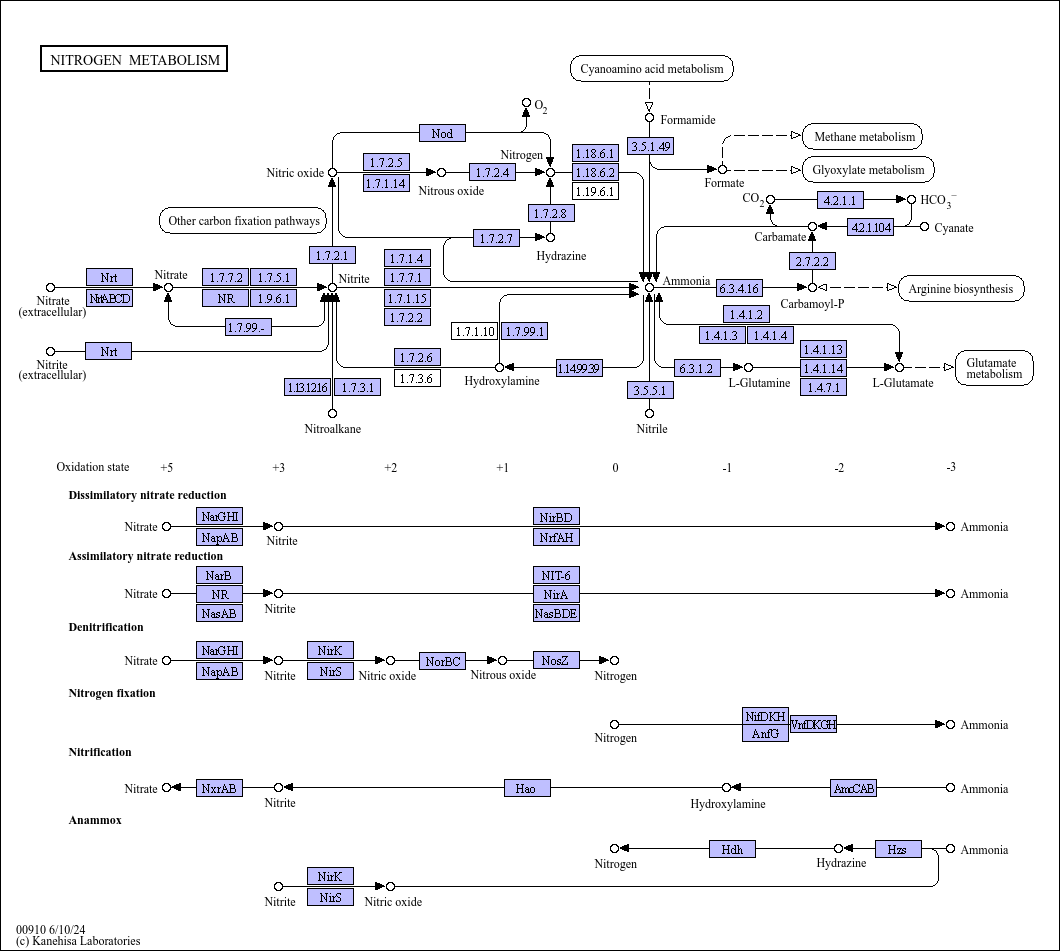

In [32]:
from IPython.display import Image, display

possible_outputs = sorted(pathview_plus_dir.glob("*00910*.png"))

print("Possible Pathview Plus output files:")
for file in possible_outputs:
    print(file)

if possible_outputs:
    display(Image(filename=str(possible_outputs[0])))
else:
    print("No PNG output found yet.")

Final Pathview Plus output exists: True
Final Pathview Plus output path: results/rhizobium/23-06-01_rhizobium/step_10-visualizeData/combined/pathview_plus_outputs/ko00910.rhizobium_vs_non_rhizobium_nitrogen_metabolism.png


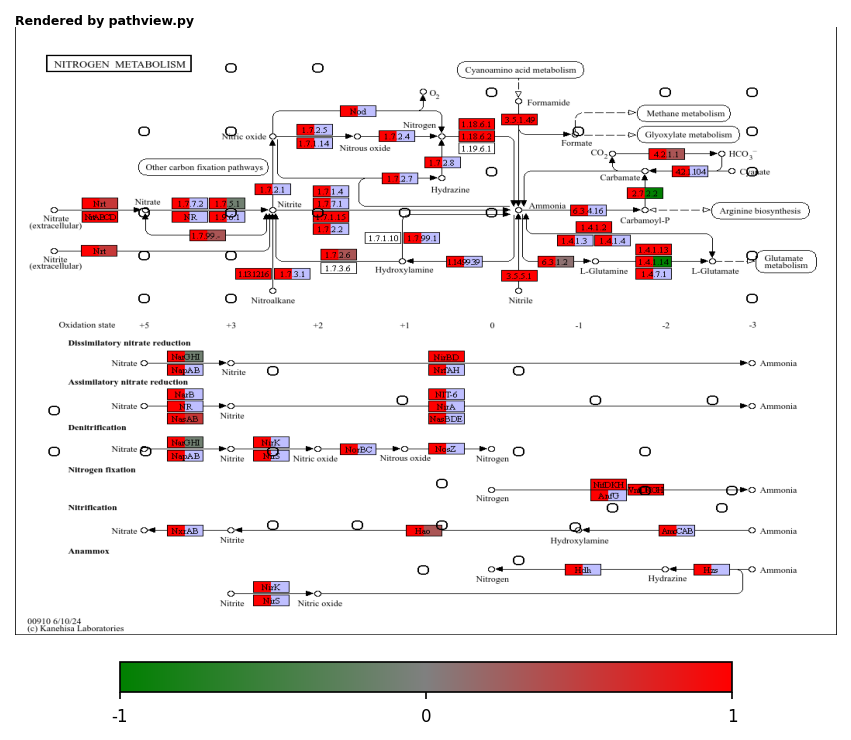

In [33]:
from IPython.display import Image, display

final_pathview_png = pathview_plus_dir / "ko00910.rhizobium_vs_non_rhizobium_nitrogen_metabolism.png"

print("Final Pathview Plus output exists:", final_pathview_png.exists())
print("Final Pathview Plus output path:", final_pathview_png)

display(Image(filename=str(final_pathview_png)))

## Pathview Plus result

Pathview Plus successfully rendered the KEGG nitrogen metabolism pathway using the Rhizobium minus Non-Rhizobium KO presence difference table.

The mapped value represents:

Rhizobium mean KO presence minus Non-Rhizobium mean KO presence

Positive values indicate KOs that are more frequently present in Rhizobium genomes. Negative values indicate KOs that are more frequently present in Non-Rhizobium genomes.

This connects the same MetaCerberus KEGG output used in pyGAGE to a pathway-level visualization.

## Pathview mapping note

Pathview Plus reported that many input IDs were unmapped.

This makes sense because the input table contains thousands of KEGG Orthology IDs from the full MetaCerberus KEGG count table, but the selected pathway is only KEGG nitrogen metabolism. Only KOs that belong to or map onto that pathway can be visualized on this specific diagram.

Because of that, the unmapped ID count does not mean the run failed. It means most KOs in the full count table are outside the selected pathway.

In [34]:
plot_data_gene = nitrogen_pathview_result.get("plot_data_gene")

print("plot_data_gene type:", type(plot_data_gene))

if plot_data_gene is not None:
    print("Mapped Pathview gene data shape:", plot_data_gene.shape)
    print("Columns:")
    print(plot_data_gene.columns)
    display(plot_data_gene.head(20))
else:
    print("No mapped gene data returned.")

plot_data_gene type: <class 'polars.dataframe.frame.DataFrame'>
Mapped Pathview gene data shape: (65, 14)
Columns:
['entry_id', 'name', 'type', 'x', 'y', 'width', 'height', 'bgcolor', 'label', 'shape', 'reaction', 'component', 'size', 'value']


entry_id,name,type,x,y,width,height,bgcolor,label,shape,reaction,component,size,value
str,str,str,f64,f64,f64,f64,str,str,str,str,str,i64,f64
"""14""","""ko:K01455 ko:K28761""","""ortholog""",650.0,146.0,46.0,17.0,"""#BFBFFF""","""K01455...""","""rectangle""","""rn:R00524""","""""",1,1.0
"""26""","""ko:K10535""","""ortholog""",417.0,357.0,46.0,17.0,"""#BFBFFF""","""K10535""","""rectangle""","""rn:R10164""","""""",1,0.2
"""27""","""ko:K10534""","""ortholog""",225.0,298.0,46.0,17.0,"""#BFBFFF""","""K10534""","""rectangle""","""rn:R00794 rn:R00796""","""""",1,null
"""28""","""ko:K02567 ko:K02568""","""ortholog""",273.0,298.0,46.0,17.0,"""#BFBFFF""","""K02567...""","""rectangle""","""rn:R03071""","""""",1,null
"""29""","""ko:K00370 ko:K00371 ko:K00374 …","""ortholog""",248.0,327.0,46.0,17.0,"""#BFBFFF""","""K00370...""","""rectangle""","""rn:R00798""","""""",1,0.2
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""42""","""ko:K04561 ko:K02305""","""ortholog""",386.0,162.0,46.0,17.0,"""#BFBFFF""","""K04561...""","""rectangle""","""rn:R00294""","""""",1,null
"""43""","""ko:K28504 ko:K10945 ko:K10946""","""ortholog""",579.0,368.0,46.0,17.0,"""#BFBFFF""","""K28504...""","""rectangle""","""rn:R00148""","""""",1,null
"""45""","""ko:K15877""","""ortholog""",386.0,183.0,46.0,17.0,"""#BFBFFF""","""K15877""","""rectangle""","""rn:R02492 rn:R09446 rn:R09808 …","""""",1,null


## Mapped pathway data check

I inspected the `plot_data_gene` object returned by Pathview Plus to confirm that the output contains mapped pathway information and not only a blank/base KEGG image.

This is important because a pathway image can sometimes render even when very few values map. Checking the returned mapped data helps confirm that the visualization is connected to the input values.

# Final workflow summary

This notebook tested the handoff from MetaCerberus rhizobium output into pyGAGE and Pathview Plus.

The main steps were:

1. I inspected the MetaCerberus rhizobium output folder.
2. I found that `FOAM_Loading_Matrix.tsv` was a loading/PCA-style table, not the best direct pyGAGE input.
3. I moved to the count tables, especially `counts_KEGG.tsv`, because it has KEGG Orthology IDs and sample columns.
4. I used the repo-defined Rhizobium and Non-Rhizobium groups to set up the comparison.
5. I treated the table as functional presence/absence data rather than expression data.
6. I ran a small nitrogenase-related pyGAGE sanity check.
7. I then pulled the official KEGG nitrogen metabolism pathway and ran pyGAGE on the KOs present in the MetaCerberus output.
8. I created a Pathview Plus input table using Rhizobium mean presence minus Non-Rhizobium mean presence.
9. I rendered the KEGG nitrogen metabolism pathway with Pathview Plus.

The main result is that KEGG nitrogen metabolism showed a positive Rhizobium signal in pyGAGE, and the same comparison could be visualized through Pathview Plus.

## Limitations and next steps

This notebook is a first workflow test, not a final biological study.

The input values are mostly binary, so the results should be interpreted as functional presence/absence or functional potential, not gene expression.

The next steps would be:

1. compare the Pathview Plus output to the existing MetaCerberus/Pathview output,
2. test more KEGG pathways beyond nitrogen metabolism,
3. decide whether FOAM or KEGG outputs are better suited for different parts of the workflow,
4. document which MetaCerberus output files are best for pyGAGE and which are best for Pathview Plus,

In [35]:
from pathlib import Path
import shutil

# Main save folder
export_dir = Path("/content/metacerberus_rhizobium_pygage_pathview_export")
export_dir.mkdir(parents=True, exist_ok=True)

# Source files
important_files = {
    "counts_KEGG.tsv": counts_kegg_path,
    "counts_FOAM.tsv": counts_foam_path,
    "stats.tsv": stats_path,
    "pathview_input_rhizobium_vs_non_rhizobium.csv": pathview_input_path,
    "pathview_nitrogen_metabolism.png": final_pathview_png,
}

# Copy files that exist
for new_name, old_path in important_files.items():
    old_path = Path(old_path)
    if old_path.exists():
        shutil.copy(old_path, export_dir / new_name)
        print("Copied:", new_name)
    else:
        print("Missing:", old_path)

print("\nExport folder:")
print(export_dir)

Copied: counts_KEGG.tsv
Copied: counts_FOAM.tsv
Copied: stats.tsv
Copied: pathview_input_rhizobium_vs_non_rhizobium.csv
Copied: pathview_nitrogen_metabolism.png

Export folder:
/content/metacerberus_rhizobium_pygage_pathview_export


In [36]:
shutil.make_archive("/content/metacerberus_rhizobium_pygage_pathview_export", "zip", export_dir)

print("Created zip:")
print("/content/metacerberus_rhizobium_pygage_pathview_export.zip")

Created zip:
/content/metacerberus_rhizobium_pygage_pathview_export.zip


In [37]:
from google.colab import files

files.download("/content/metacerberus_rhizobium_pygage_pathview_export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>